In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import corner
from astropy.cosmology import Planck18 as cosmo
from VegasAfterglow import ObsData, Setups, Fitter, ParamDef, Scale

plt.rcParams["font.family"] = "arial"
plt.rcParams["font.size"] = 18


In [163]:
path = './data/'
######### 1. PREPARE DATA #########
# Prepare your data in .csv format, following the format of example data.
# Create an instance of the ObsData class to store light curve and spectrum data
data = ObsData()

# Define the frequency bands [Hz] and corresponding light curve files

z = 0.0099
d_L = cosmo.luminosity_distance(z).to('cm').value

hz_band = [3e9, 5.5e9, 6e9, 6.2e9, 7.25e9, 9e9, 4.946e14, 3.68e14]
mw_data = ['radio_3.csv', 'radio_5.5.csv', 'radio_6.csv', 'radio_6.2.csv', 'radio_7.25.csv', 'radio_9.csv', 'optical_v.csv', 'optical_i.csv']
mw_name = ['3 GHz', '5.5 GHz', '6 GHz', '6.2 GHz', '7.25 GHz', '9 GHz', 'v', 'i']

# Loop through each frequency band and corresponding file(s)
for nu, fname in zip(hz_band, mw_data):
    df = pd.read_csv(path + fname)
    f = df['Fv_obs']
    f_err = 0.5 * (df['Fv_obs_err_pos'] + df['Fv_obs_err_neg'])

    data.add_flux_density(nu=nu, t=df["t"], f_nu=f, err=f_err, weights=np.ones(len(df["t"])))


xray_min, xray_max = np.array([0.3e3, 8e3]) * 2.418e14
xray_data = "chandra_data.csv"
xray_name = "Chandra 0.3-8 keV"

df_X = pd.read_csv(path + xray_data)
t_X = df_X["t"]
f_X = df_X['L'] / (4 * np.pi * d_L**2 + (1 + z))
f_X_err_pos = df_X['L_err_pos'] / (4 * np.pi * d_L**2 + (1 + z))
f_X_err_neg = df_X['L_err_neg'] / (4 * np.pi * d_L**2 + (1 + z))
f_X_err = 0.5 * (f_X_err_pos + f_X_err_neg)

data.add_flux(nu_min=xray_min, nu_max=xray_max, num_points=10, t=t_X, flux=f_X, err=f_X_err, weights=5 * np.ones(len(t_X)))

In [164]:

######### 2. CONFIGURE MODEL #########
cfg = Setups()
cfg.lumi_dist = d_L   # Luminosity distance [cm]  
cfg.z         = z        # Redshift
cfg.medium    = "ism"      # Medium type: "wind", "ism" (Interstellar Medium)
cfg.jet       = "gaussian"  # Jet structure: "powerlaw", "gaussian", "tophat", "two_component", "step_powerlaw" 

mc_params = [
    ParamDef("E_iso",    1e51,  1e54,  Scale.LOG),       # Isotropic energy [erg]
    ParamDef("Gamma0",    100,  1000,  Scale.LOG),       # Lorentz factor at the core
    ParamDef("n_ism",    1e-4,   1e-2,  Scale.LOG),       # ISM number density [cm^-3]
    ParamDef("theta_c",   0.0,   0.5,  Scale.LINEAR),    # Core half-opening angle [rad]
    ParamDef("theta_w",   0.0,  1.57,  Scale.LINEAR),    # Wing truncation angle [rad]
    ParamDef("theta_v",   0.0,  1.57,  Scale.LINEAR),     # Viewing angle [rad]
    ParamDef("p",         2.1,     2.5,  Scale.LINEAR),    # Power law index
    ParamDef("eps_e",    1e-4,   1e-1,  Scale.LOG),       # Electron energy fraction
    ParamDef("eps_B",    1e-5,   1e-2,  Scale.LOG),       # Magnetic field energy fraction
    ParamDef("xi_e",     1e-3,    1e-1,  Scale.LOG),       # Efficiency factor
]

In [165]:
######### 4. RUN MCMC #########
# Create an instance of the MCMC Fitter class using the prepared data and configuration
fitter = Fitter(data, cfg)
 
# Run the fitting process using the defined parameters for specified number of MCMC steps (total_steps)
result = fitter.fit(
    mc_params,
    total_steps=100000,
    burn_frac=0.3,
    top_k=10
)

# Create a table for top-k parameters
top_k_data = []
for i in range(result.top_k_params.shape[0]):
    row = {'Rank': i+1, 'chi^2': f"{-2*result.top_k_log_probs[i]:.2f}"}
    for name, val in zip(result.labels, result.top_k_params[i]):
        row[name] = f"{val:.4f}"
    top_k_data.append(row)

top_k_df = pd.DataFrame(top_k_data)
print("Top-k parameters:")
print(top_k_df.to_string(index=False))

100%|██████████| 100000/100000 [39:35<00:00, 42.10it/s]


Top-k parameters:
 Rank  chi^2   E_iso Gamma0   n_ism theta_c theta_w theta_v      p   eps_e   eps_B    xi_e
    1 303.24 53.0798 2.9899 -3.4872  0.0454  0.1751  0.2414 2.1852 -1.8825 -3.7555 -1.3958
    2 303.40 53.0864 2.9903 -3.4838  0.0454  0.1675  0.2412 2.1852 -1.8860 -3.7677 -1.4073
    3 303.77 52.2615 2.9920 -4.4697  0.0417  0.1552  0.2287 2.1752 -2.0799 -1.4442 -1.1675
    4 303.90 52.4105 2.9911 -4.5171  0.0393  0.7569  0.2173 2.1722 -2.2878 -1.3709 -1.2932
    5 303.95 52.2057 2.9988 -4.7293  0.0360  0.1612  0.2153 2.1656 -2.0038 -1.1591 -0.8919
    6 303.95 52.4099 2.9917 -4.5240  0.0392  0.7602  0.2169 2.1721 -2.2907 -1.3616 -1.2931
    7 304.00 52.2393 2.9972 -4.6822  0.0363  0.1621  0.2163 2.1660 -2.0330 -1.2119 -0.9301
    8 304.07 53.2888 2.9513 -3.1044  0.0482  0.1780  0.2549 2.1883 -2.5460 -3.4810 -1.9326
    9 304.16 53.0865 2.9997 -3.5064  0.0455  0.1651  0.2396 2.1865 -1.8473 -3.8173 -1.4003
   10 304.18 52.1873 2.9963 -4.6896  0.0367  0.1331  0.2198 2.1645 -1.99

In [166]:
# Define time and frequency ranges for predictions
t_out = np.logspace(4, 9, 100)

best_params = result.top_k_params[0]
print(best_params)
# best_params = [
# 53.07,
# 2.946,
# -3.455,
# 0.03864,
# 0.8322,
# 0.2462,
# 2.162,
# -2.503,
# -2.501,
# -1.072,
# ]

top = result.top_k_params[:10]
avg_params = np.mean(top, axis=0) 


mw_fit = fitter.flux_density_grid(best_params, t_out, hz_band)
xray_fit = fitter.flux(best_params, t_out, xray_min, xray_max, num_points=100)



[ 5.30797977e+01  2.98990941e+00 -3.48722069e+00  4.53834490e-02
  1.75101525e-01  2.41424168e-01  2.18516120e+00 -1.88247201e+00
 -3.75551444e+00 -1.39580461e+00]


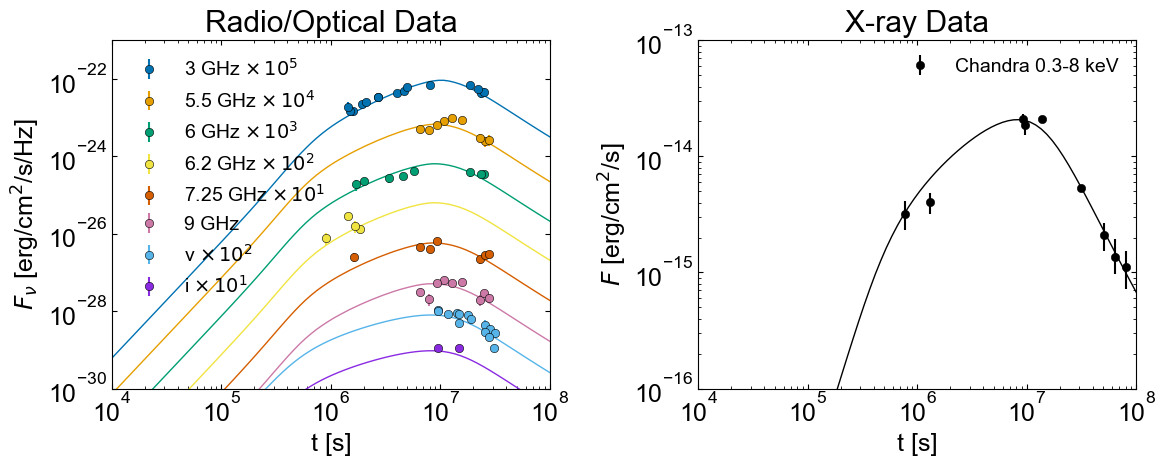

In [167]:
# Function to plot model light curves along with observed data
def draw_combined(t_mw, mw_fit, mw_files, t_x, xray_fit, xray_file):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 cols

    # --- MW plot ---
    colors = [
        '#0072B2', '#E69F00', '#009E73', '#F0E442',
        '#D55E00', '#CC79A7', '#56B4E9', '#8A2BE2'
    ]
    shifts = [1e5, 1e4, 1e3, 1e2, 1e1, 1, 1e2, 1e1]

    for i, file in enumerate(mw_files):
        sft = shifts[i]
        c = colors[i]
        df = pd.read_csv(path + file)
        if sft > 1:
            label = rf"{mw_name[i]} $\times \, 10^{{{int(np.log10(sft))}}}$"
        else:
            label = mw_name[i]
        ax1.errorbar(
            df["t"],
            df["Fv_obs"]*sft,
            yerr=[df["Fv_obs_err_neg"]*sft, df["Fv_obs_err_pos"]*sft],
            fmt='o', color=c, markersize=6, label=label,
            markeredgecolor='k', markeredgewidth=0.4
        )
        ax1.plot(t_mw, mw_fit[i,:]*sft, lw=1, color=c)

    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('t [s]')
    ax1.set_ylabel(r'$F_\nu$ [erg/cm$^2$/s/Hz]')
    ax1.set_xlim(1e4, 1e8)
    ax1.set_ylim(1e-30, 1e-21)
    ax1.legend(frameon=False, fontsize=14)
    ax1.set_title('Radio/Optical Data')
    ax1.tick_params(axis='x', which='both', top=True, direction='in')
    ax1.tick_params(axis='y', which='both', right=True, direction='in')


    # --- X-ray plot ---
    df = pd.read_csv(path + xray_file)
    Fv_obs = df['L'] / (4 * np.pi * d_L**2 * (1 + z))
    Fv_obs_err_neg = df['L_err_neg'] / (4 * np.pi * d_L**2 * (1 + z))
    Fv_obs_err_pos = df['L_err_pos'] / (4 * np.pi * d_L**2 * (1 + z))

    ax2.plot(t_x, np.array(xray_fit), lw=1, color='k')
    ax2.errorbar(
        df["t"], Fv_obs,
        yerr=[Fv_obs_err_neg, Fv_obs_err_pos],
        fmt='o', color='k', markersize=6,
        label=xray_name, markeredgecolor='k', markeredgewidth=0.4
    )
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlim(1e4, 1e8)
    ax2.set_ylim(1e-16, 1e-13)
    ax2.set_xlabel('t [s]')
    ax2.set_ylabel(r'$F$ [erg/cm$^2$/s]')
    ax2.legend(frameon=False, fontsize=14)
    ax2.set_title('X-ray Data')
    ax2.tick_params(axis='x', which='both', top=True, direction='in')
    ax2.tick_params(axis='y', which='both', right=True, direction='in')


    plt.tight_layout()
    plt.savefig('best_fit.pdf', bbox_inches='tight', pad_inches=0.05)

    plt.show()

# Usage
draw_combined(t_out, mw_fit, mw_data, t_out, xray_fit, xray_data)


Parameter medians (50% quantile):
E_iso: 52.94
Gamma0: 2.934
n_ism: -3.551
theta_c: 0.04434
theta_w: 0.8074
theta_v: 0.2498
p: 2.181
eps_e: -2.104
eps_B: -3.031
xi_e: -1.261
Corner plot saved to: corner_plot.pdf


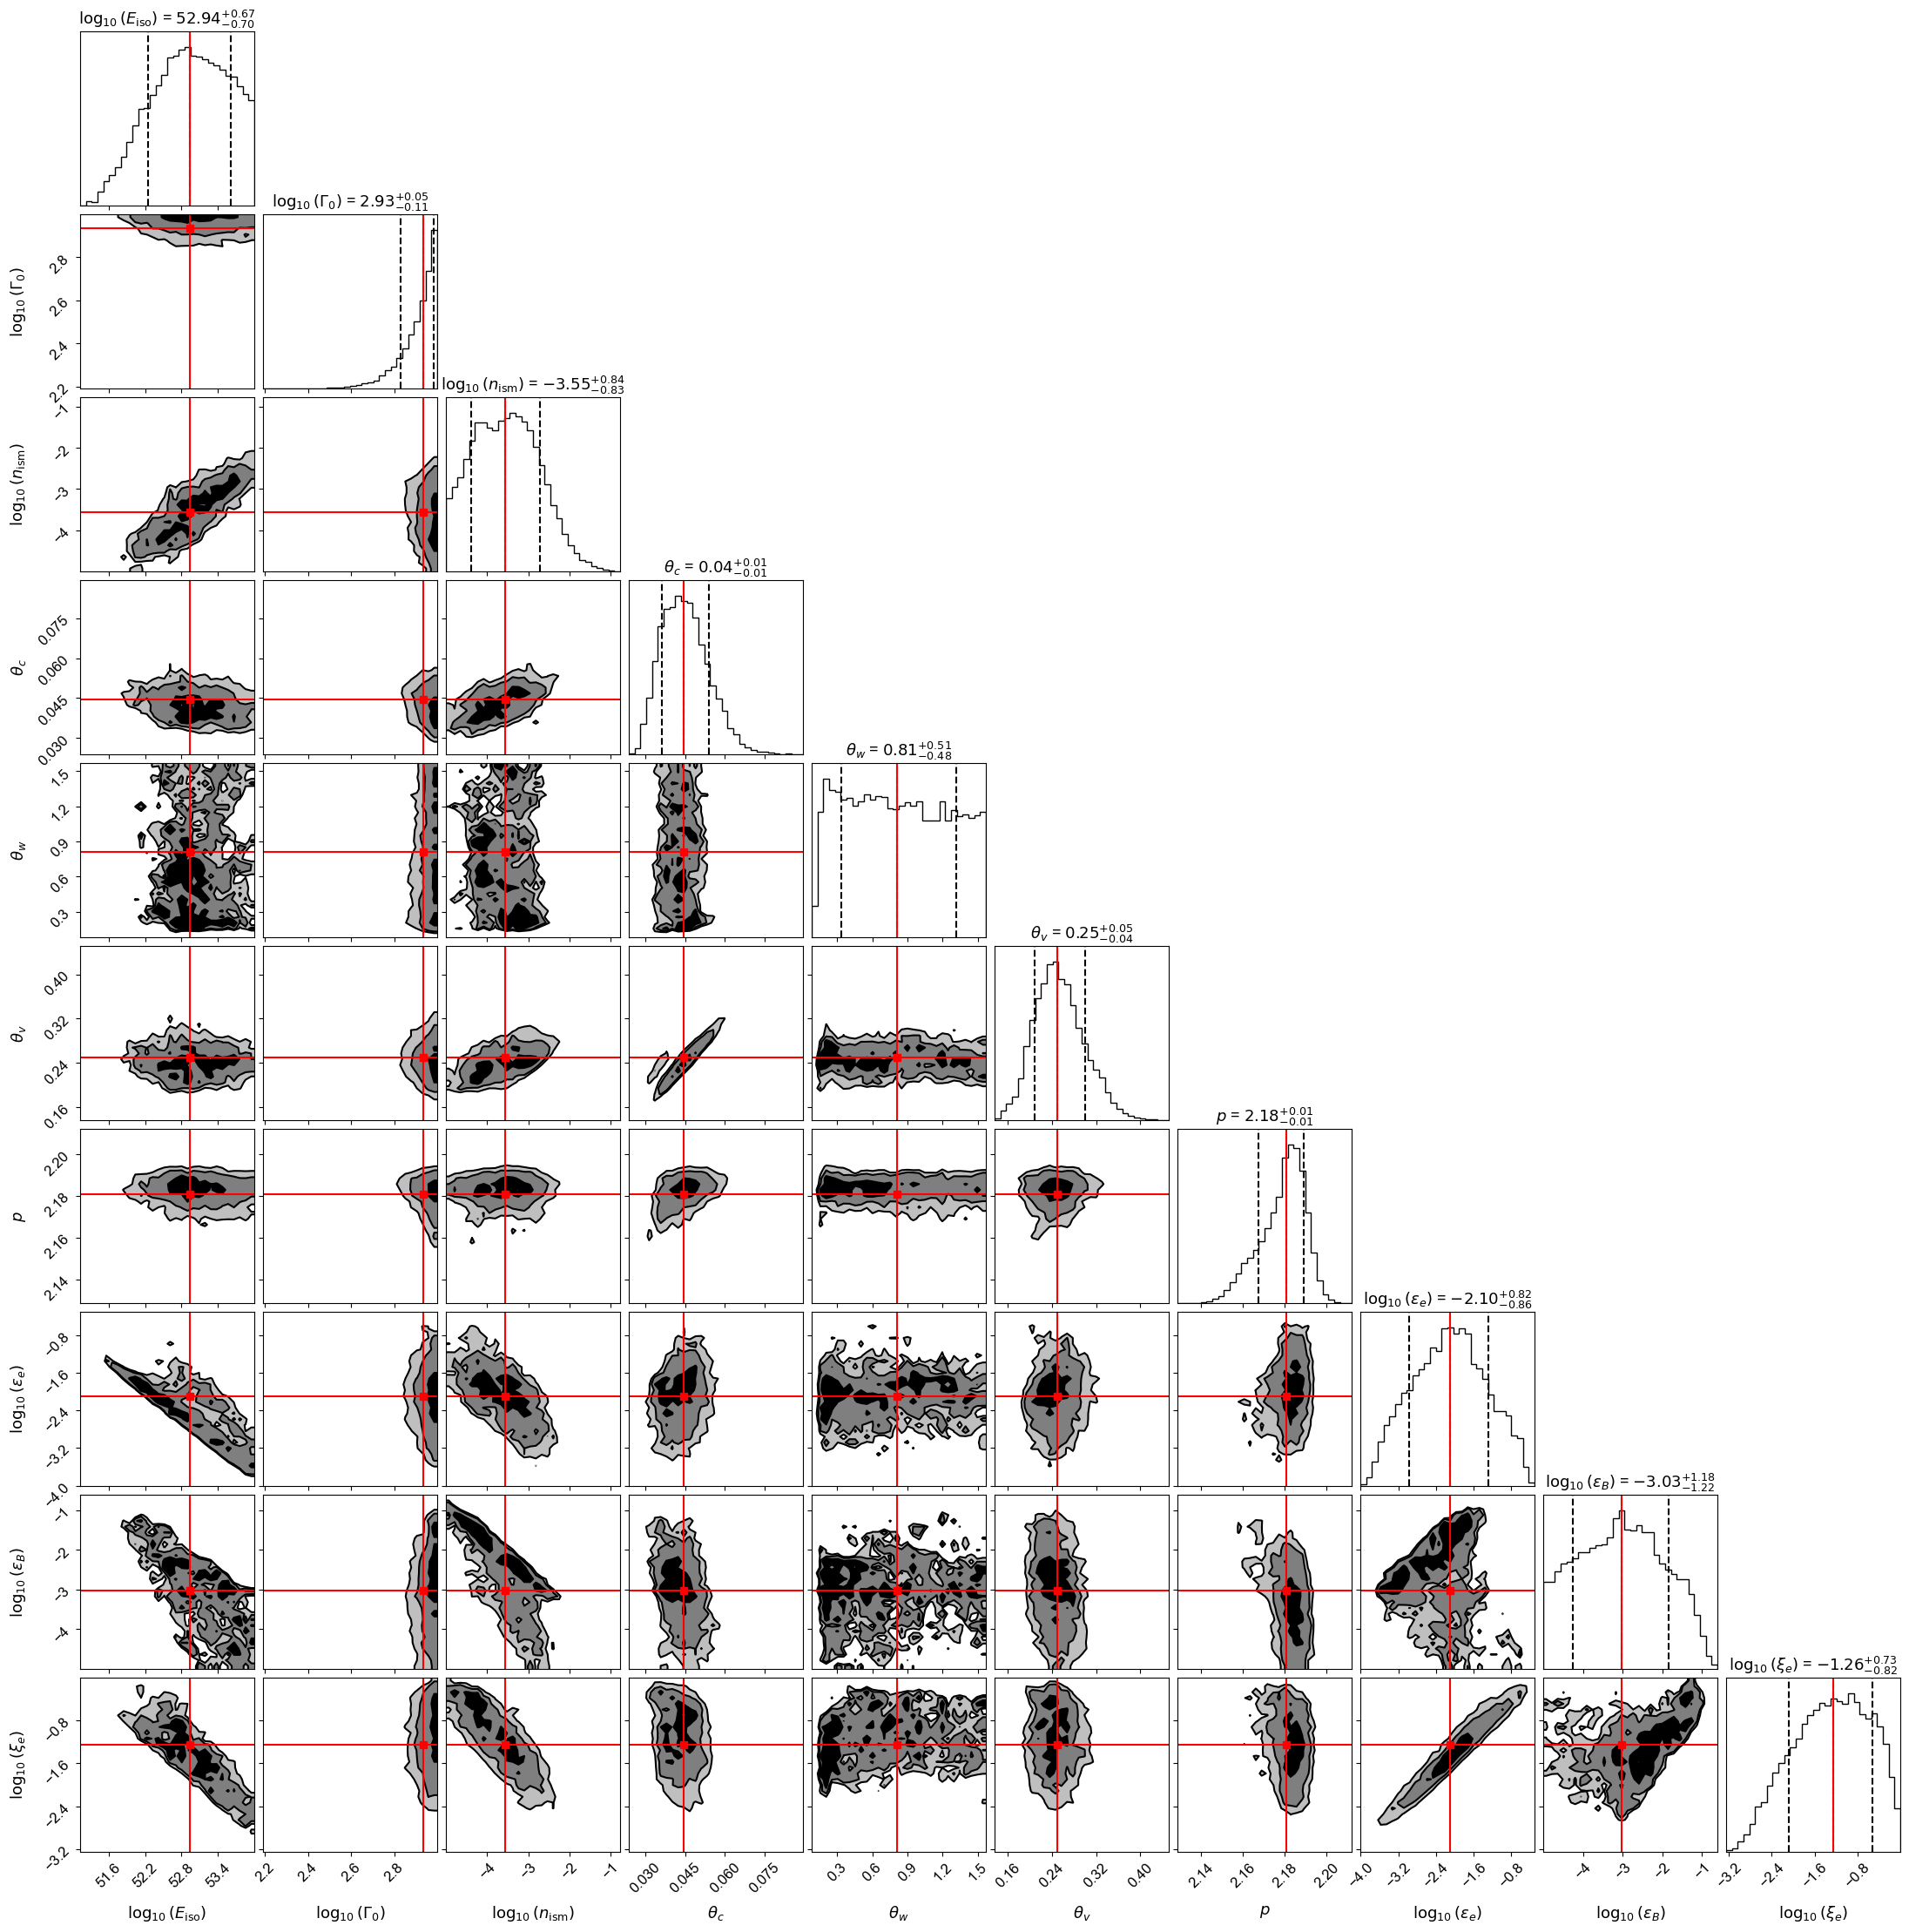

In [168]:
# Function to create a corner plot showing parameter correlations and confidence intervals
def plot_corner(flat_chain, labels, filename="corner_plot.pdf"):
    fig = corner.corner(
        flat_chain,
        labels=labels,
        quantiles=[0.16, 0.5, 0.84],  # For median and ±1σ
        show_titles=True,
        title_kwargs={"fontsize": 13},
        label_kwargs={"fontsize": 13},
        #range=ranges,  # Optional: constrain plot ranges
        truths=np.median(flat_chain, axis=0),  # Show median values
        truth_color='red',
        smooth=0.2,
        bins=30,  # Number of bins in histograms
        plot_datapoints=False,
        fill_contours=True,
        levels=[0.16, 0.5, 0.68],  # 1σ and 2σ contours
        color='k',
        alpha=0.5
    )
    for ax in fig.get_axes():
        ax.tick_params(axis='both', labelsize=12) 
    fig.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Corner plot saved to: {filename}")

# Function to make a trace plot to show MCMC convergence over steps
def plot_trace(chain, labels, filename="trace_plot.png"):
    nsteps, nwalkers, ndim = chain.shape
    fig, axes = plt.subplots(ndim, figsize=(10, 2.5 * ndim), sharex=True)

    for i in range(ndim):
        for j in range(nwalkers):
            axes[i].plot(chain[:, j, i], alpha=1,lw=0.5)
        axes[i].set_ylabel(labels[i])
        axes[i].grid(True)
    
    axes[-1].set_xlabel("Step")
    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"Trace plot saved to: {filename}")

# plot_trace(result.samples, result.labels, filename="trace_plot.png")

flat_chain = result.samples.reshape(-1, result.samples.shape[-1])

# Compute medians
medians = np.median(flat_chain, axis=0)

# Print parameter names with median values
print("Parameter medians (50% quantile):")
for name, val in zip(result.labels, medians):
    print(f"{name}: {val:.4g}")

latex_labels = [
    r"$\log_{10}(E_{\rm iso})$",
    r"$\log_{10}(\Gamma_0)$",
    r"$\log_{10}(n_{\rm ism})$",
    r"$\theta_c$",
    r"$\theta_w$",
    r"$\theta_v$",
    r"$p$",
    r"$\log_{10}(\epsilon_e)$",
    r"$\log_{10}(\epsilon_B)$",
    r"$\log_{10}(\xi_e)$"
]

plot_corner(flat_chain, latex_labels, filename="corner_plot.pdf")